# Data engineer

In [56]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt', quiet=True)
print("All required NLTK resources downloaded!")

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

All required NLTK resources downloaded!


In [57]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.tokenize import TweetTokenizer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords, wordnet
from nltk import pos_tag
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer
from nltk import ngrams


import pandas as pd
import numpy as np
import re
import nltk
from nltk.tokenize import TweetTokenizer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from textblob import TextBlob
from wordcloud import WordCloud

import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import style
style.use('ggplot')
from textblob import TextBlob
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


In [58]:
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [59]:
col_names = ['Id', 'Entity', 'Sentiment', 'Content']
train_data = pd.read_csv('twitter_training.csv', names=col_names, header=None)
valid_data = pd.read_csv('twitter_validation.csv', names=col_names, header=None)

In [60]:
train_data.head()


,Id,Entity,Sentiment,Content
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [61]:
train_data.shape



(74682, 4)

In [62]:
valid_data.shape


(1000, 4)

In [63]:
valid_data.head()


,Id,Entity,Sentiment,Content
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...


In [64]:
train_data.isnull().sum()

,0
Id,0
Entity,0
Sentiment,0
Content,686


In [65]:
train_data.dropna(subset=['Content'], inplace=True)
train_data.drop_duplicates(subset=['Content'], inplace=True)
train_data.reset_index(drop=True, inplace=True)

In [66]:
train_data.isnull().sum()

,0
Id,0
Entity,0
Sentiment,0
Content,0


In [67]:
train_data.info()
train_data.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69491 entries, 0 to 69490
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         69491 non-null  int64 
 1   Entity     69491 non-null  object
 2   Sentiment  69491 non-null  object
 3   Content    69491 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.1+ MB


(69491, 4)

In [68]:
#processing tools
tokenizer = TweetTokenizer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

In [69]:
#extract mentions and hashtags
def extract_mentions(text):
    if pd.isnull(text):
        return []
    return re.findall(r'@\w+', text)

def extract_hashtags(text):
    if pd.isnull(text):
        return []
    return re.findall(r'#\w+', text)

In [70]:
#add mentions and hashtags columns(feature )
train_data['mentions'] = train_data['Content'].apply(extract_mentions)
train_data['hashtags'] = train_data['Content'].apply(extract_hashtags)

In [71]:
#get wordnet pos tag
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

In [72]:
def clean_text(text):
    if pd.isnull(text):
        return ""

    # delete links
    text = re.sub(r'https?://\S+', '', text)

    # delete menshion and hashtags
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)

   # Remove special symbols and characters
    text = re.sub(r'[^A-Za-z0-9\s]', ' ', text)

    # conv to LowerCase
    text = text.lower()

    # Tokenization
    tokens = tokenizer.tokenize(text)

    # deletl stopwords
    tokens = [t for t in tokens if t not in stop_words]

    # POS tagging
    tokens_pos = pos_tag(tokens)

     # Lemmatization  with POS tagging
    tokens = [lemmatizer.lemmatize(word, get_wordnet_pos(pos)) for word, pos in tokens_pos]


    return " ".join(tokens)


In [73]:
train_data['clean_text'] = train_data['Content'].apply(clean_text)

In [74]:
train_data[['Content', 'mentions', 'hashtags', 'clean_text']].head()

,Content,mentions,hashtags,clean_text
0,im getting on borderlands and i will murder yo...,[],[],im get borderland murder
1,I am coming to the borders and I will kill you...,[],[],come border kill
2,im getting on borderlands and i will kill you ...,[],[],im get borderland kill
3,im coming on borderlands and i will murder you...,[],[],im come borderland murder
4,im getting on borderlands 2 and i will murder ...,[],[],im get borderland 2 murder


In [75]:
train_data['clean_length'] = train_data['clean_text'].apply(len)
print(train_data['clean_length'].describe())

count    69491.000000
mean        70.554072
std         49.805588
min          0.000000
25%         31.000000
50%         60.000000
75%         98.000000
max        811.000000
Name: clean_length, dtype: float64


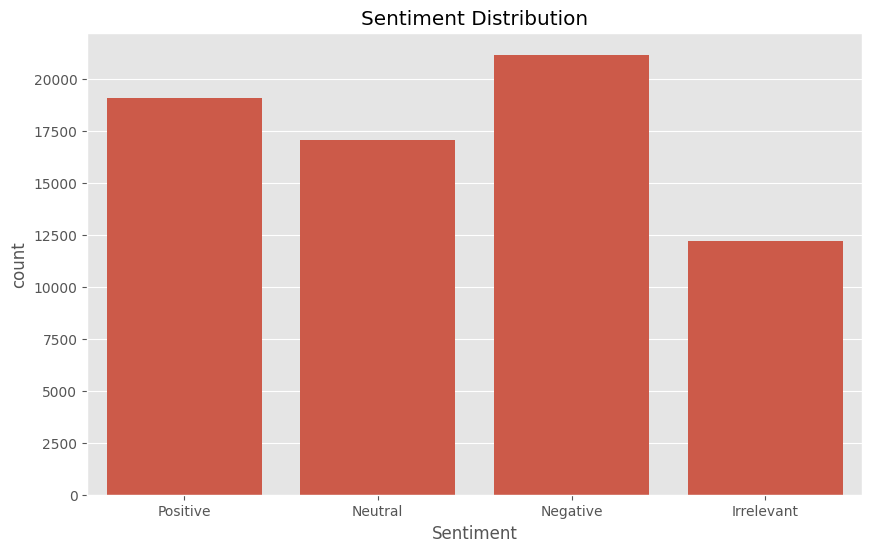

In [76]:
plt.figure(figsize=(10,6))
sns.countplot(data=train_data, x='Sentiment')
plt.title("Sentiment Distribution")
plt.show()


In [77]:
#save the cleaned data
train_data.to_csv("clean_twitter_data.csv", index=False)
print("Saved clean data!")

Saved clean data!


In [78]:
#TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), sublinear_tf=True)

X_tfidf = tfidf.fit_transform(train_data['clean_text'])

print("TF-IDF shape:", X_tfidf.shape)


TF-IDF shape: (69491, 5000)


In [79]:
#Label Encoding
le = LabelEncoder()
y = le.fit_transform(train_data['Sentiment'])

print("Classes:", le.classes_)
print("y shape:", y.shape)

Classes: ['Irrelevant' 'Negative' 'Neutral' 'Positive']
y shape: (69491,)


In [80]:
train_data['text_length'] = train_data['clean_text'].apply(lambda x: len(x.split()))
train_data['num_hashtags'] = train_data['hashtags'].apply(len)
train_data['num_mentions'] = train_data['mentions'].apply(len)

# Data Analysis

In [81]:
# Check for missing values
train_data.isnull().sum()
valid_data.isnull().sum()

,0
Id,0
Entity,0
Sentiment,0
Content,0


In [82]:
# Checking the distribution of sentiment labels
train_sentiment_distribution = train_data.iloc[:, 2].value_counts()
valid_sentiment_distribution = valid_data.iloc[:, 2].value_counts()
train_sentiment_distribution,valid_sentiment_distribution

(Sentiment
 Negative      21166
 Positive      19067
 Neutral       17042
 Irrelevant    12216
 Name: count, dtype: int64,
 Sentiment
 Neutral       285
 Positive      277
 Negative      266
 Irrelevant    172
 Name: count, dtype: int64)

In [83]:
train_data.iloc[:, 1].nunique()


32

In [84]:
train_data_cleaned = train_data.drop_duplicates(subset=['Id', 'Entity', 'Sentiment', 'Content'])

In [85]:
# Drop rows with missing tweet/message values
train_data_cleaned.dropna(subset=[train_data.columns[3]])


,Id,Entity,Sentiment,Content,mentions,hashtags,clean_text,clean_length,text_length,num_hashtags,num_mentions
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...,[],[],im get borderland murder,24,4,0,0
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,[],[],come border kill,16,3,0,0
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,[],[],im get borderland kill,22,4,0,0
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,[],[],im come borderland murder,25,4,0,0
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,[],[],im get borderland 2 murder,26,5,0,0
...,...,...,...,...,...,...,...,...,...,...,...
69486,9200,Nvidia,Positive,Just realized that the Windows partition of my...,[],[],realize window partition mac like 6 year behin...,73,12,0,0
69487,9200,Nvidia,Positive,Just realized that my Mac window partition is ...,[],[],realize mac window partition 6 year behind nvi...,68,11,0,0
69488,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...,[],[],realize window partition mac 6 year behind nvi...,68,11,0,0
69489,9200,Nvidia,Positive,Just realized between the windows partition of...,[],[],realize window partition mac like 6 year behin...,87,15,0,0


In [86]:
train_data.drop_duplicates(subset=['Content'], inplace=True)


In [87]:
 #Verify the cleaning
remaining_duplicates_train = train_data_cleaned.duplicated(subset=['Id', 'Entity', 'Sentiment', 'Content']).sum()
remaining_missing_train = train_data_cleaned.isnull().sum()

remaining_duplicates_train, remaining_missing_train

(np.int64(0),
 Id              0
 Entity          0
 Sentiment       0
 Content         0
 mentions        0
 hashtags        0
 clean_text      0
 clean_length    0
 text_length     0
 num_hashtags    0
 num_mentions    0
 dtype: int64)

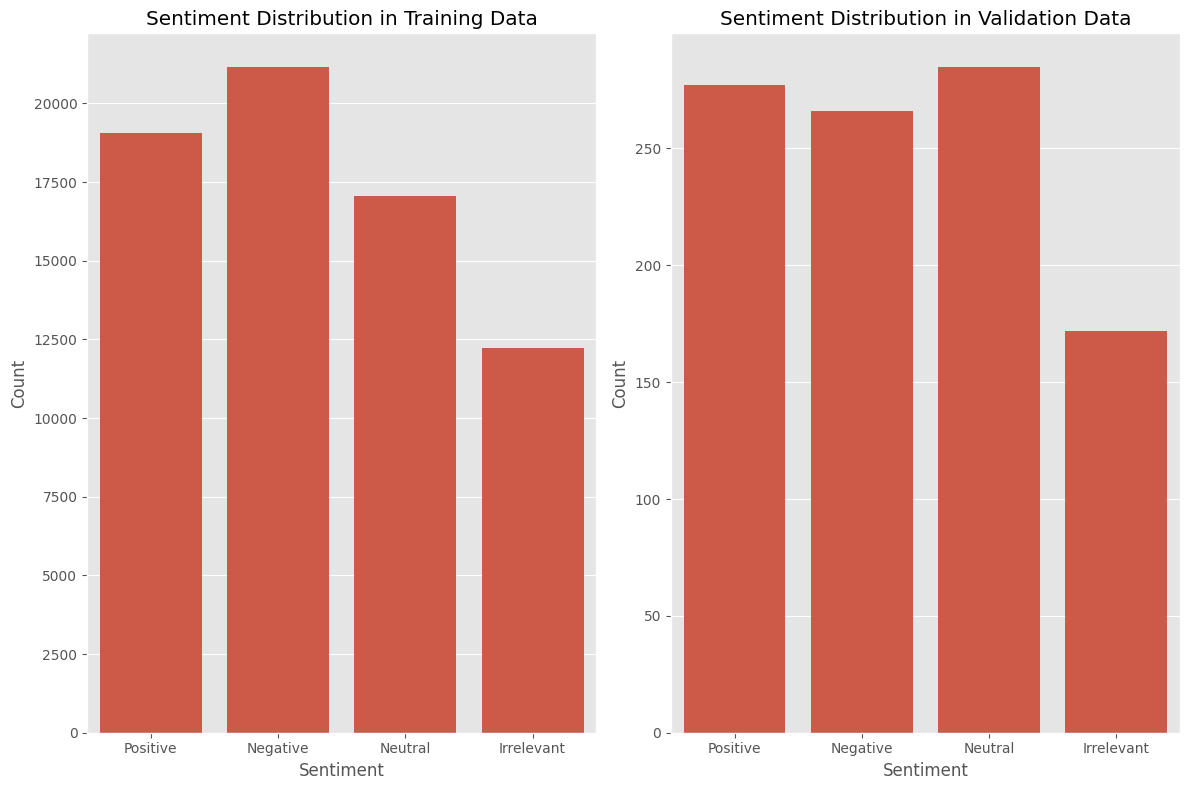

In [88]:
# Set up the plots
fig, ax = plt.subplots(1, 2, figsize=(12, 8))

# Plot sentiment distribution for training data
sns.countplot(data=train_data_cleaned, x=train_data_cleaned.columns[2], order=['Positive', 'Negative', 'Neutral','Irrelevant'], ax=ax[0])
ax[0].set_title('Sentiment Distribution in Training Data')
ax[0].set_ylabel('Count')
ax[0].set_xlabel('Sentiment')

# Plot sentiment distribution for validation data
sns.countplot(data=valid_data, x=valid_data.columns[2], order=['Positive', 'Negative', 'Neutral', 'Irrelevant'], ax=ax[1])
ax[1].set_title('Sentiment Distribution in Validation Data')
ax[1].set_ylabel('Count')
ax[1].set_xlabel('Sentiment')

plt.tight_layout()
plt.show()

In [89]:
train_data_cleaned['message_length'] = train_data_cleaned[train_data_cleaned.columns[3]].fillna('').apply(len)
valid_data['message_length'] = valid_data[valid_data.columns[3]].fillna('').apply(len)


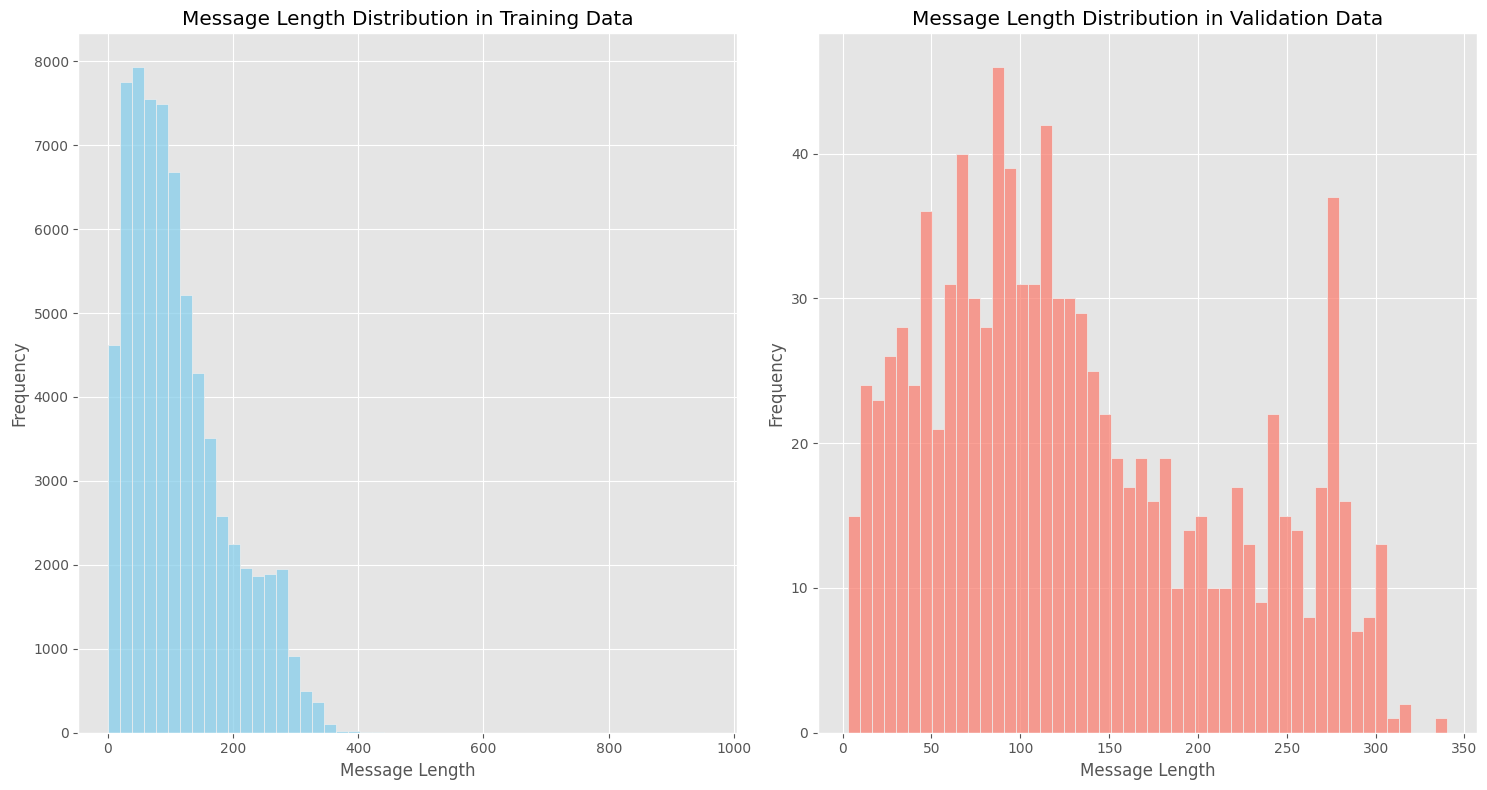

In [90]:
fig, ax = plt.subplots(1, 2, figsize=(15, 8))

# Plot message length distribution for training data
sns.histplot(train_data_cleaned['message_length'], bins=50, ax=ax[0], color='skyblue')
ax[0].set_title('Message Length Distribution in Training Data')
ax[0].set_ylabel('Frequency')
ax[0].set_xlabel('Message Length')

# Plot message length distribution for validation data
sns.histplot(valid_data['message_length'], bins=50, ax=ax[1], color='salmon')
ax[1].set_title('Message Length Distribution in Validation Data')
ax[1].set_ylabel('Frequency')
ax[1].set_xlabel('Message Length')

plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

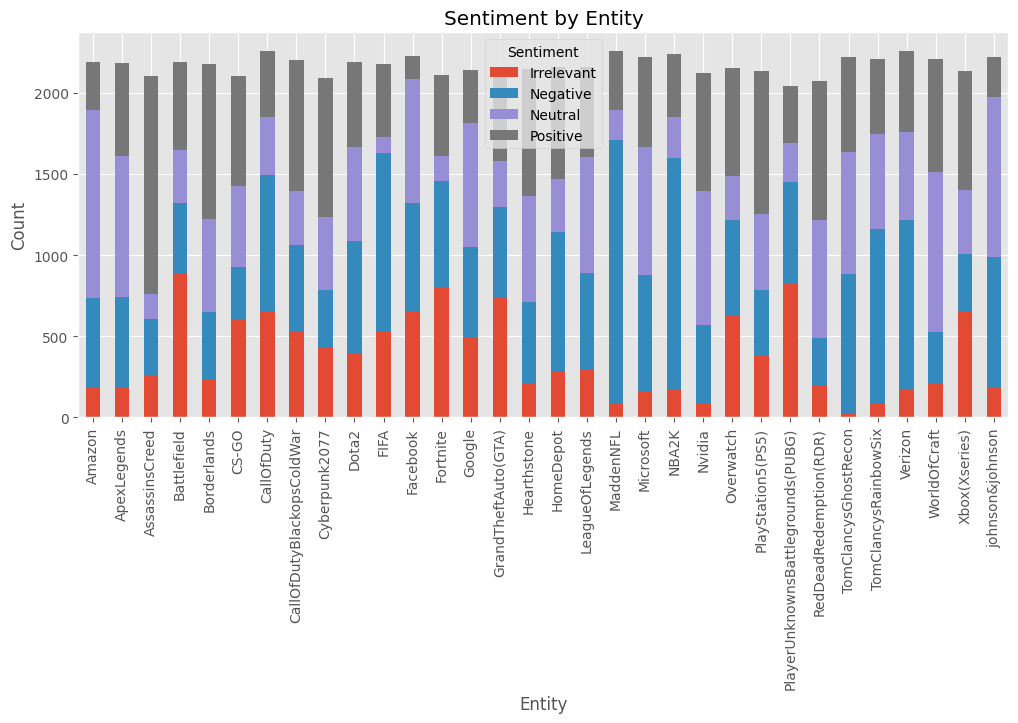

In [91]:
plt.figure(figsize=(10,5))
train_data.groupby(["Entity", "Sentiment"]).size().unstack().plot(kind="bar", stacked=True , figsize=(12,5))
plt.title("Sentiment by Entity")
plt.xlabel("Entity")
plt.ylabel("Count")
plt.show()


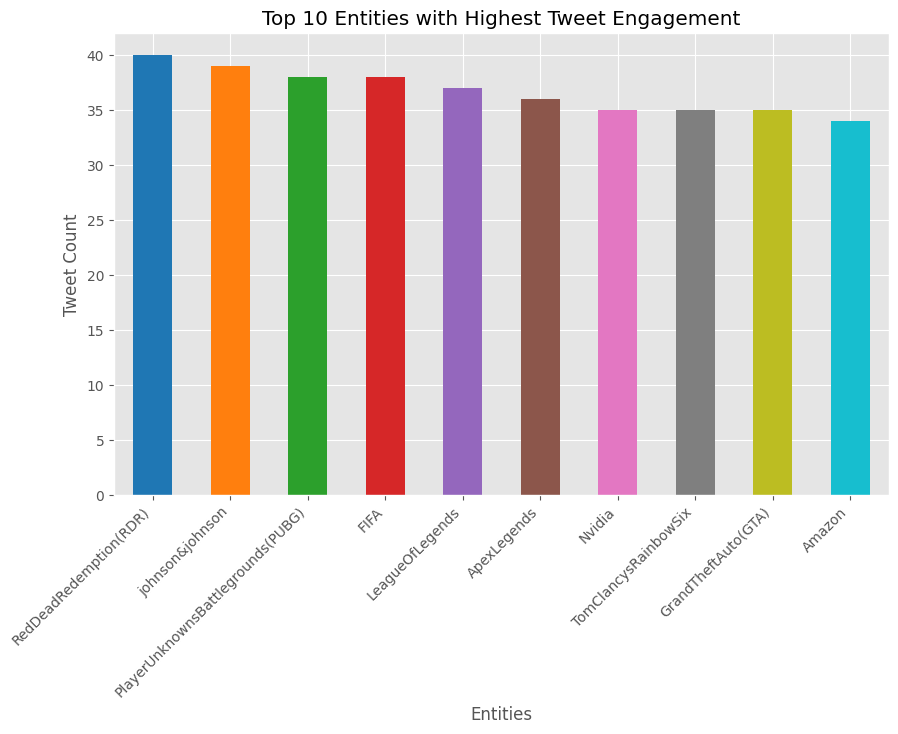

In [92]:
#Bar Chart representation of top 10 most engaged entities on tweets
# Count the occurrences of each category
entity_counts = valid_data['Entity'].value_counts()

# Select the top 10 categories
top_10_entity = entity_counts.head(10)

# Define colors for the bars
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

# Plot a bar graph for the top 10 categories with colors
plt.figure(figsize=(10, 6))
top_10_entity.plot(kind='bar', color=colors)

# Remove the annotate part to not show values on top of each bar

plt.xlabel("Entities")
plt.ylabel('Tweet Count')
plt.title('Top 10 Entities with Highest Tweet Engagement')
plt.xticks(rotation=45, ha='right')  # Adjust rotation for better readability
plt.show()

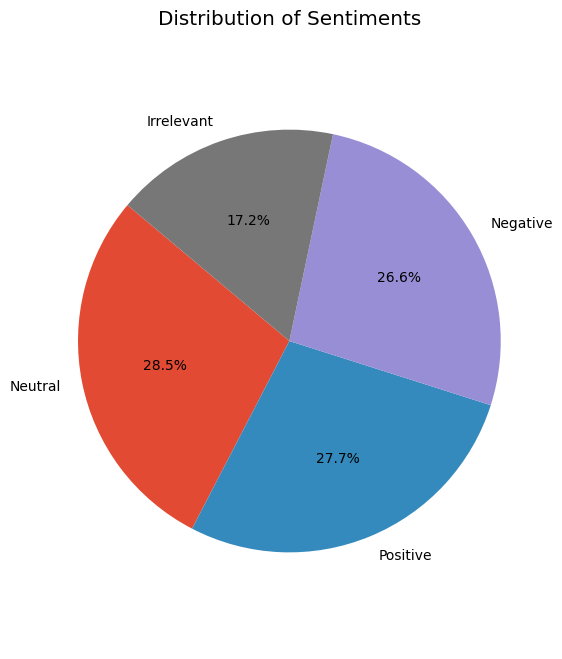

In [93]:
category_counts = valid_data['Sentiment'].value_counts()

# Plot a pie chart
plt.figure(figsize=(6, 8))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=140)
plt.axis('equal')

plt.title('Distribution of Sentiments')
plt.show()

/tmp/ipython-input-1099678249.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_data_cleaned, y=train_data_cleaned.columns[1], order=train_data_cleaned[train_data_cleaned.columns[1]].value_counts().index, palette='viridis')


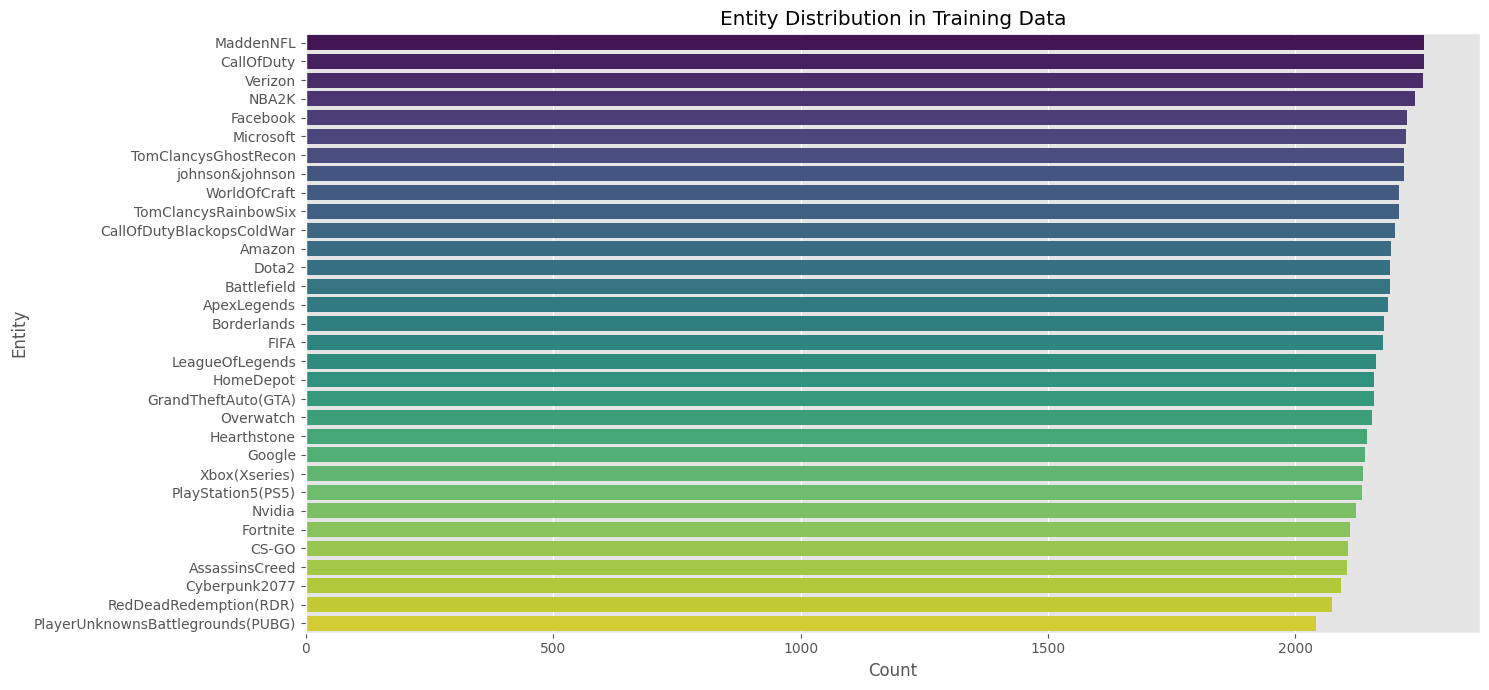

In [94]:
plt.figure(figsize=(15, 7))

# Plot entity distribution for training data
sns.countplot(data=train_data_cleaned, y=train_data_cleaned.columns[1], order=train_data_cleaned[train_data_cleaned.columns[1]].value_counts().index, palette='viridis')
plt.title('Entity Distribution in Training Data')
plt.xlabel('Count')
plt.ylabel('Entity')
plt.tight_layout()
plt.show()

In [95]:
top_entities = train_data['Entity'].value_counts().nlargest(10).index
train_data_top = train_data[train_data['Entity'].isin(top_entities)]

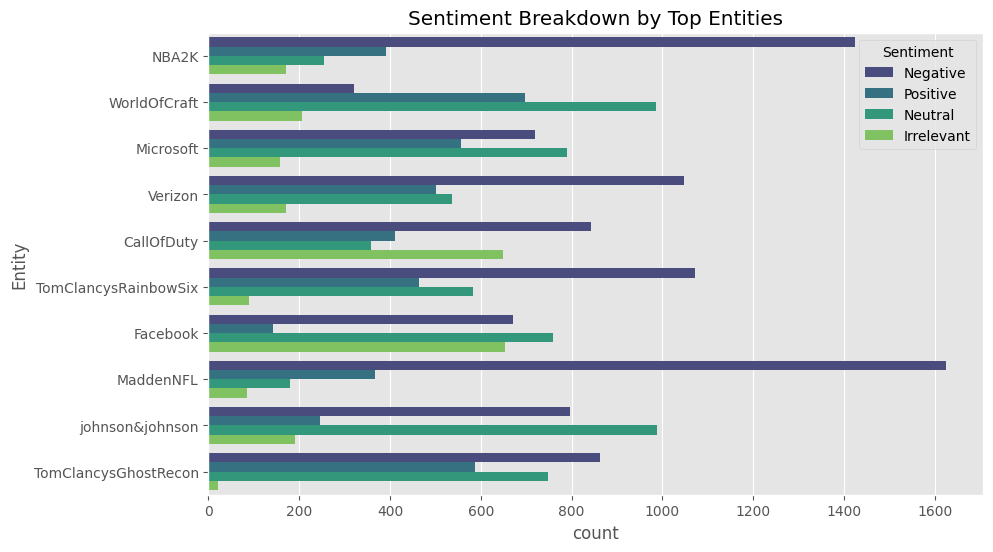

In [96]:
plt.figure(figsize=(10, 6))
sns.countplot(y='Entity', hue='Sentiment', data=train_data_top, palette='viridis')
plt.title('Sentiment Breakdown by Top Entities')
plt.show()

/tmp/ipython-input-2792879266.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_data_cleaned, x=train_data_cleaned.columns[2], y='message_length', ax=ax[0], palette='viridis', order=['Positive', 'Negative', 'Neutral', 'Irrelevant'])
/tmp/ipython-input-2792879266.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=valid_data, x=valid_data.columns[2], y='message_length', ax=ax[1], palette='viridis', order=['Positive', 'Negative', 'Neutral', 'Irrelevant'])


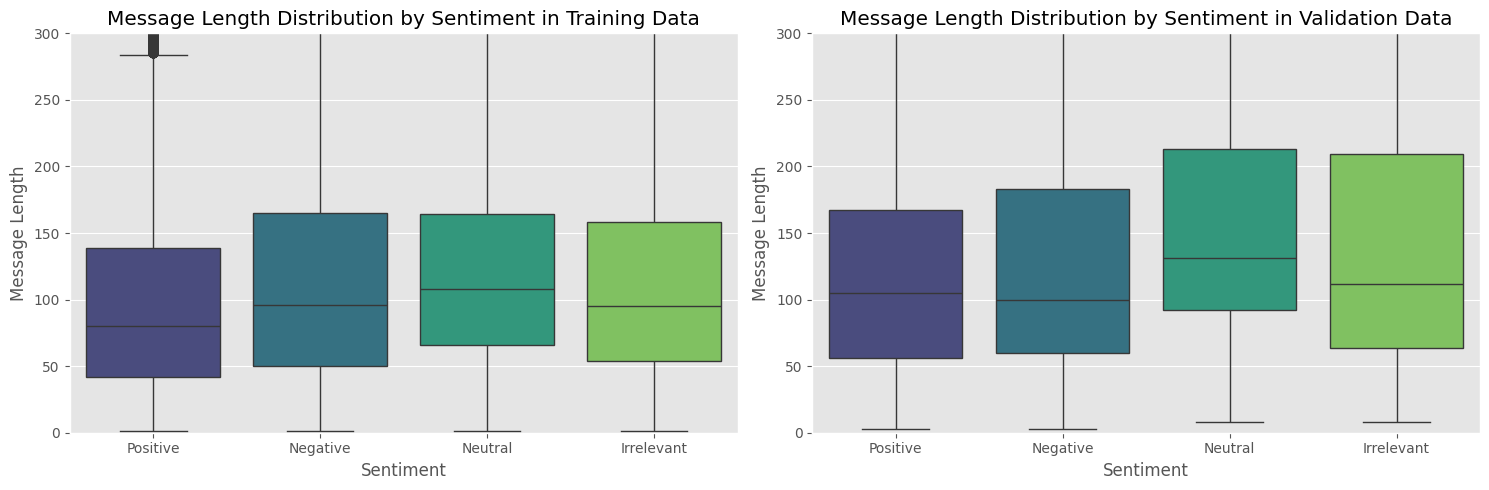

In [97]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Plot message length distribution by sentiment for training data
sns.boxplot(data=train_data_cleaned, x=train_data_cleaned.columns[2], y='message_length', ax=ax[0], palette='viridis', order=['Positive', 'Negative', 'Neutral', 'Irrelevant'])
ax[0].set_title('Message Length Distribution by Sentiment in Training Data')
ax[0].set_ylabel('Message Length')
ax[0].set_xlabel('Sentiment')
ax[0].set_ylim(0, 300)

# Plot message length distribution by sentiment for validation data
sns.boxplot(data=valid_data, x=valid_data.columns[2], y='message_length', ax=ax[1], palette='viridis', order=['Positive', 'Negative', 'Neutral', 'Irrelevant'])
ax[1].set_title('Message Length Distribution by Sentiment in Validation Data')
ax[1].set_ylabel('Message Length')
ax[1].set_xlabel('Sentiment')
ax[1].set_ylim(0, 300)

plt.tight_layout()
plt.show()

In [98]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

# Replace "tweet" with the actual column name, e.g., "text"
train_data["clean_tweet"] = train_data["Content"].astype(str).apply(clean_text)

In [99]:
from collections import Counter
def get_top_words(sentiment, n=20):
    text = " ".join(train_data[train_data["Sentiment"] == sentiment]["clean_tweet"])
    words = text.split()
    counter = Counter(words)
    return counter.most_common(n)

In [100]:
print("Top 20 words in Positive tweets:", get_top_words("Positive"))
print("Top 20 words in Negative tweets:", get_top_words("Negative"))
print("Top 20 words in Neutral tweets:", get_top_words("Neutral"))
print("Top 20 words in Irrelevant tweets:", get_top_words("Irrelevant"))

Top 20 words in Positive tweets: [('the', 11407), ('i', 8841), ('to', 7371), ('and', 6756), ('a', 5776), ('of', 4911), ('is', 4309), ('for', 4289), ('this', 4113), ('it', 3883), ('in', 3707), ('my', 3212), ('on', 2755), ('so', 2664), ('you', 2472), ('that', 2349), ('game', 2221), ('with', 2170), ('be', 1775), ('but', 1732)]
Top 20 words in Negative tweets: [('the', 13633), ('i', 9932), ('to', 8849), ('and', 8516), ('a', 7368), ('is', 6675), ('of', 5585), ('this', 4829), ('in', 4730), ('it', 4681), ('you', 4388), ('for', 4228), ('my', 4106), ('on', 3766), ('game', 3738), ('that', 3651), ('with', 2799), ('not', 2608), ('so', 2413), ('me', 2341)]
Top 20 words in Neutral tweets: [('the', 10131), ('to', 6863), ('and', 6206), ('a', 5794), ('i', 5385), ('of', 4700), ('for', 3943), ('in', 3923), ('is', 3237), ('on', 3136), ('this', 2751), ('it', 2736), ('you', 2381), ('my', 2369), ('with', 2205), ('that', 1950), ('johnson', 1742), ('just', 1588), ('at', 1493), ('me', 1420)]
Top 20 words in Irr

In [101]:
from nltk import ngrams

def get_bigrams(sentiment):
    text = " ".join(train_data[train_data["Sentiment"] == sentiment]["clean_tweet"])
    tokens = text.split()
    bigrams = list(ngrams(tokens, 2))
    counter = Counter(bigrams)
    return counter.most_common(20)

print("Top bigrams (Positive):", get_bigrams("Positive"))
print("Top bigrams (Negative):", get_bigrams("Negative"))

Top bigrams (Positive): [(('of', 'the'), 794), (('i', 'love'), 763), (('in', 'the'), 705), (('the', 'best'), 627), (('this', 'is'), 615), (('for', 'the'), 607), (('and', 'i'), 591), (('red', 'dead'), 570), (('thank', 'you'), 533), (('assassins', 'creed'), 521), (('dead', 'redemption'), 474), (('the', 'game'), 473), (('cant', 'wait'), 473), (('on', 'the'), 450), (('to', 'be'), 422), (('i', 'am'), 407), (('to', 'play'), 398), (('the', 'new'), 389), (('to', 'the'), 385), (('so', 'much'), 373)]
Top bigrams (Negative): [(('the', 'game'), 883), (('in', 'the'), 869), (('of', 'the'), 743), (('this', 'is'), 729), (('and', 'i'), 645), (('i', 'have'), 572), (('i', 'cant'), 509), (('is', 'a'), 496), (('on', 'the'), 464), (('for', 'the'), 461), (('to', 'the'), 417), (('when', 'i'), 402), (('this', 'game'), 397), (('home', 'depot'), 395), (('i', 'am'), 394), (('to', 'be'), 379), (('to', 'play'), 369), (('to', 'get'), 353), (('with', 'the'), 348), (('is', 'the'), 345)]


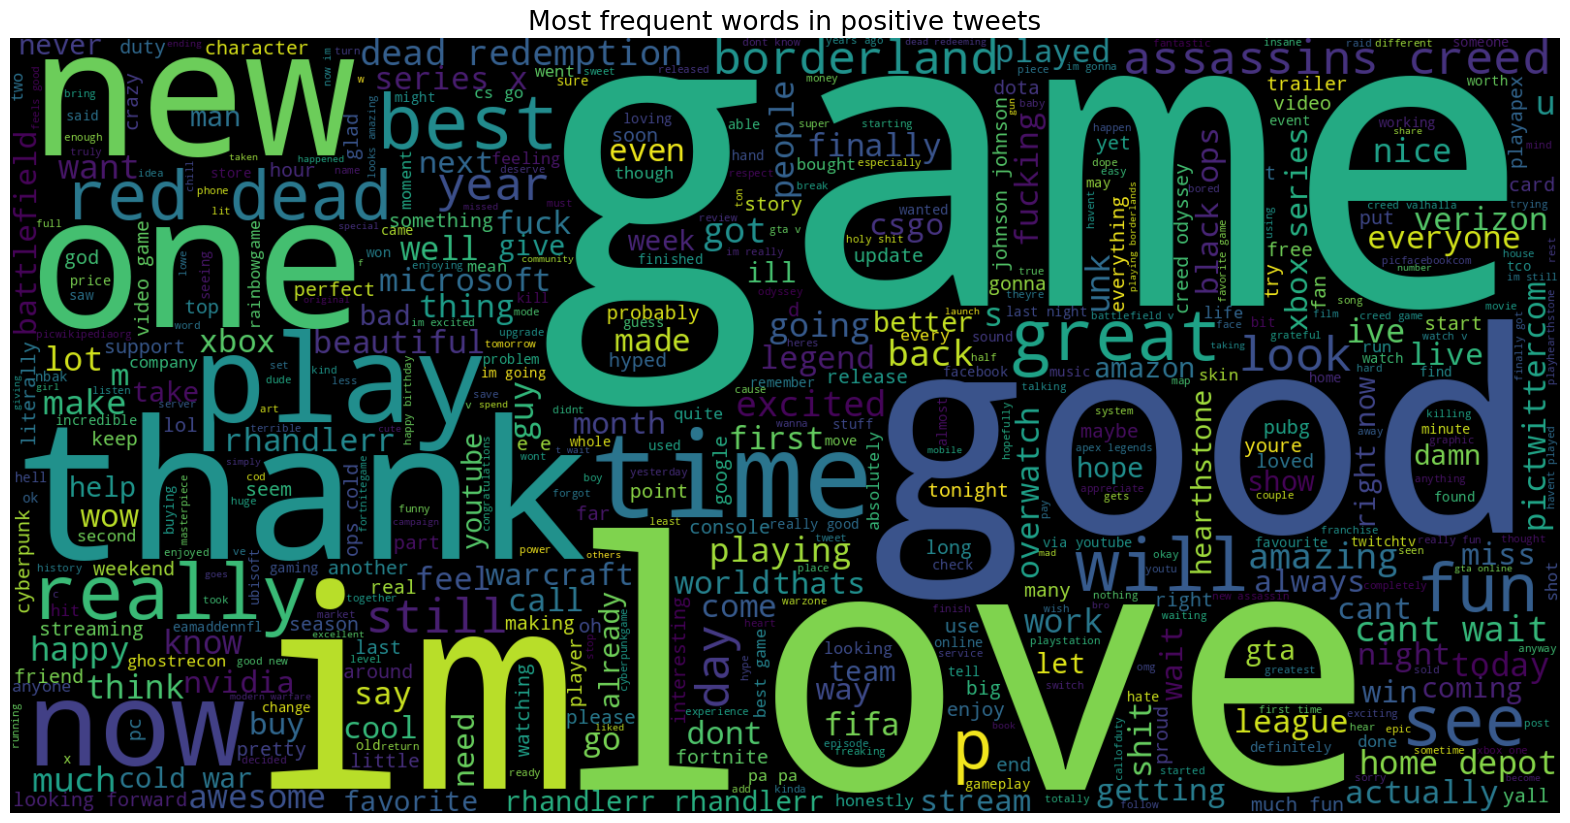

In [102]:
##Most frequent words in positive tweets
pos_tweets = train_data[train_data['Sentiment'] == 'Positive']

text = ' '.join([word for word in pos_tweets['clean_tweet']])
plt.figure(figsize=(20,15), facecolor='None')
wordcloud = WordCloud(max_words=500, width=1600, height=800).generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title('Most frequent words in positive tweets', fontsize=19)
plt.show()

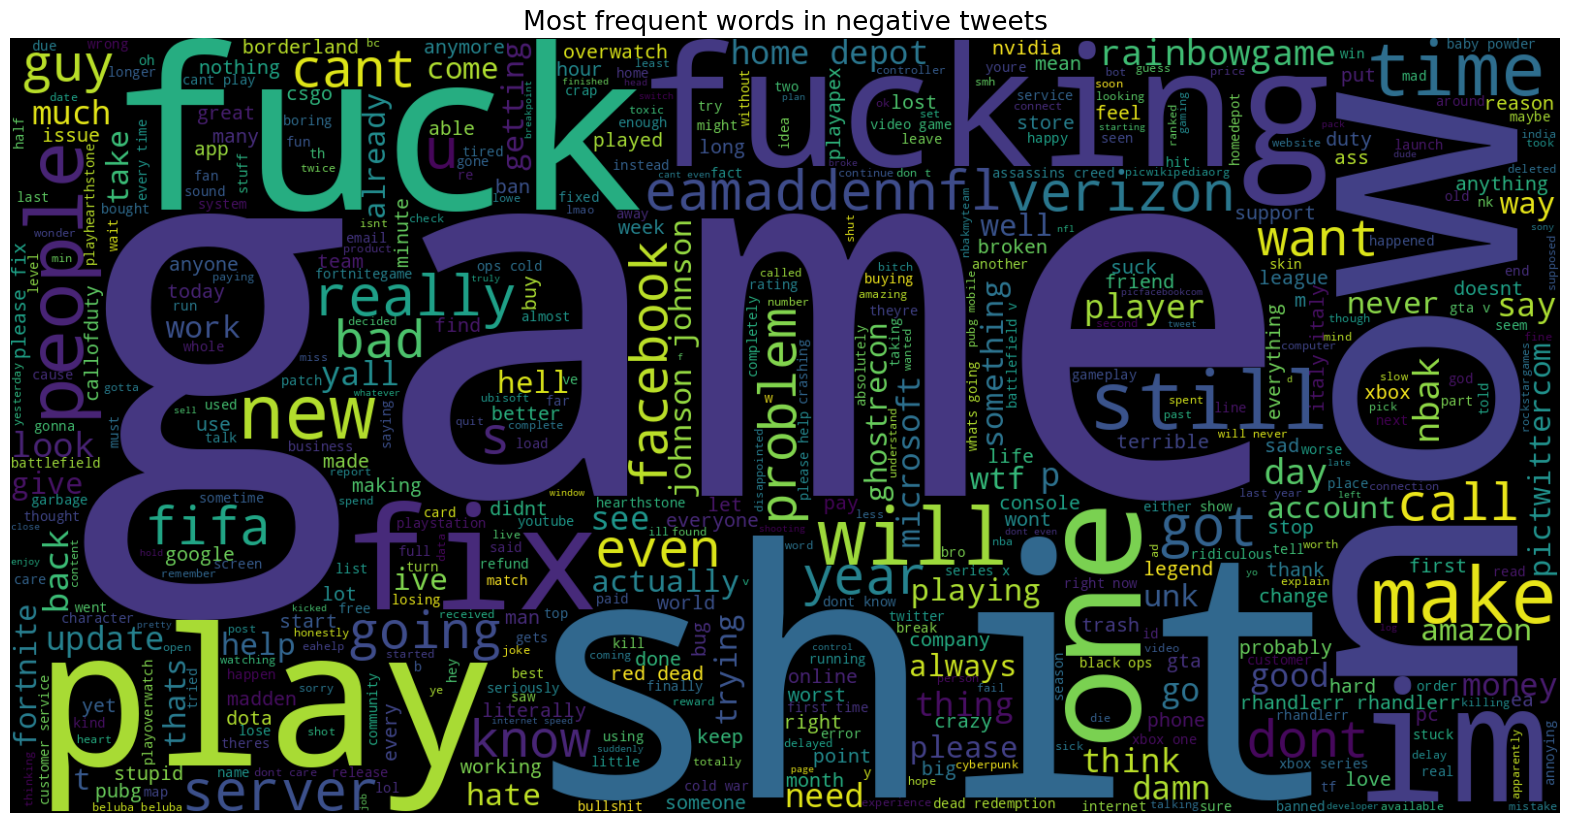

In [103]:
##Most frequent words in negative tweets
neg_tweets = train_data[train_data['Sentiment'] == 'Negative']
text = ' '.join([word for word in neg_tweets['clean_tweet']])
plt.figure(figsize=(20,15), facecolor='None')
wordcloud = WordCloud(max_words=500, width=1600, height=800).generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title('Most frequent words in negative tweets', fontsize=19)
plt.show()

In [104]:
def extract_mentions(text):
    return re.findall(r"@\w+", text)

train_data["mentions"] = train_data["Content"].apply(lambda x: extract_mentions(str(x)))

# Flatten list
all_mentions = [m for sublist in train_data["mentions"] for m in sublist]

mention_counts = Counter(all_mentions)
print("Top 20 mentioned users:", mention_counts.most_common(20))

Top 20 mentioned users: [('@EAMaddenNFL', 829), ('@Rainbow6Game', 731), ('@NBA2K', 705), ('@GhostRecon', 467), ('@PlayApex', 405), ('@CallofDuty', 338), ('@Verizon', 259), ('@YouTube', 221), ('@Ubisoft', 220), ('@verizon', 214), ('@FortniteGame', 194), ('@PlayHearthstone', 186), ('@HomeDepot', 173), ('@Borderlands', 171), ('@UbisoftSupport', 171), ('@Ronnie2K', 167), ('@NBA2K_MyTEAM', 152), ('@nvidia', 150), ('@DOTA2', 145), ('@LeagueOfLegends', 127)]


/tmp/ipython-input-3257394348.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(freqs), y=list(words), palette='Greens_d')


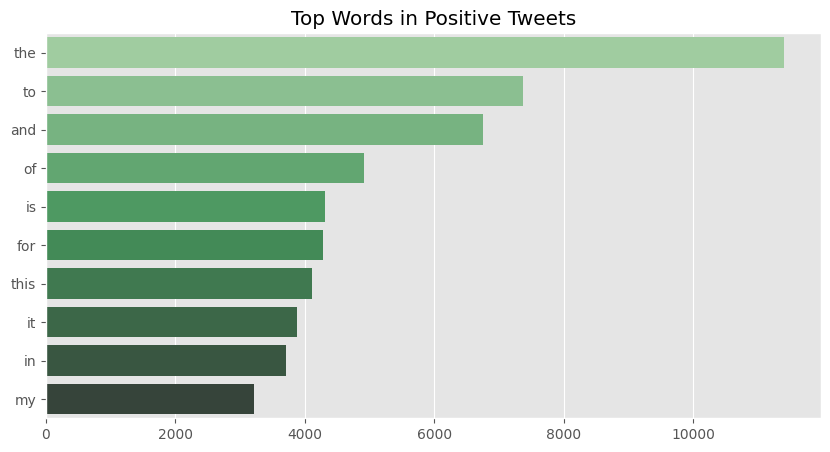

/tmp/ipython-input-3257394348.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(freqs), y=list(words), palette='Reds_d')


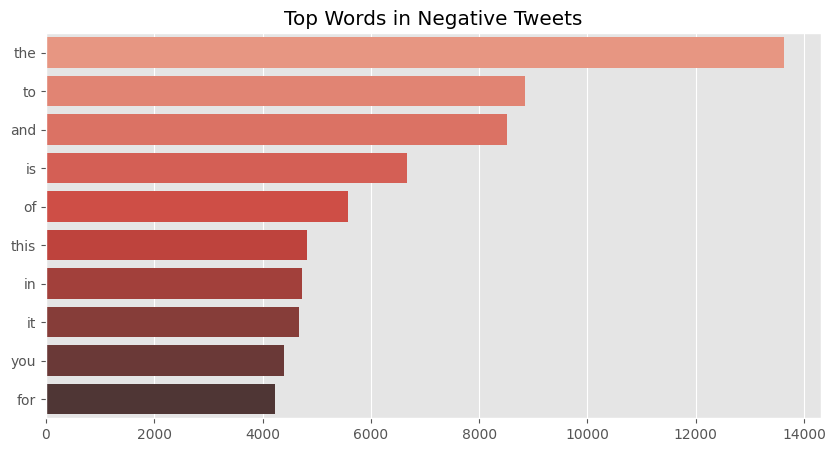

In [105]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_words(corpus, n=10):
    vec = CountVectorizer().fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

pos_words = get_top_words(train_data[train_data['Sentiment']=='Positive']['clean_tweet'])
words, freqs = zip(*pos_words)

plt.figure(figsize=(10, 5))
sns.barplot(x=list(freqs), y=list(words), palette='Greens_d')
plt.title('Top Words in Positive Tweets')
plt.show()

neg_words = get_top_words(train_data[train_data['Sentiment']=='Negative']['clean_tweet'])
words, freqs = zip(*neg_words)

plt.figure(figsize=(10, 5))
sns.barplot(x=list(freqs), y=list(words), palette='Reds_d')
plt.title('Top Words in Negative Tweets')
plt.show()

In [106]:
# Define a function to handle non-string values
def analyze_sentiment(text):
    if isinstance(text, str):
        return TextBlob(text).sentiment.polarity
    else:
        return 0.0


In [107]:
# Perform sentiment analysis
train_data['Polarity'] = train_data['Content'].apply(analyze_sentiment)

# Categorize sentiment
train_data['Sentiment_Label'] = train_data['Polarity'].apply(lambda x: 'Positive' if x > 0 else 'Negative' if x < 0 else 'Neutral')



In [108]:
# Perform sentiment analysis
valid_data['Polarity'] = valid_data['Content'].apply(analyze_sentiment)

# Categorize sentiment
valid_data['Sentiment_Label'] = valid_data['Polarity'].apply(lambda x: 'Positive' if x > 0 else 'Negative' if x < 0 else 'Neutral')



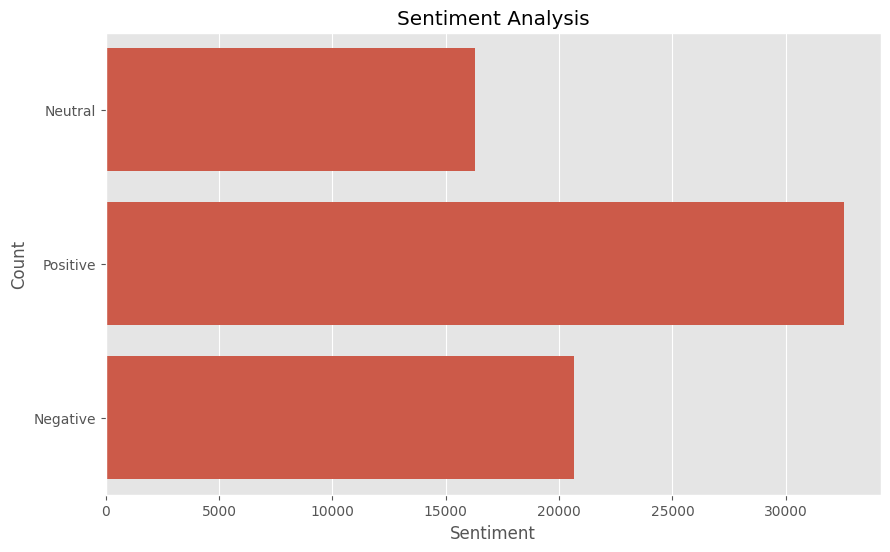

In [109]:
# Analyze sentiment distribution
plt.figure(figsize=(10, 6))
sns.countplot(train_data['Sentiment_Label'])
plt.title('Sentiment Analysis')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

<Figure size 2000x1000 with 0 Axes>

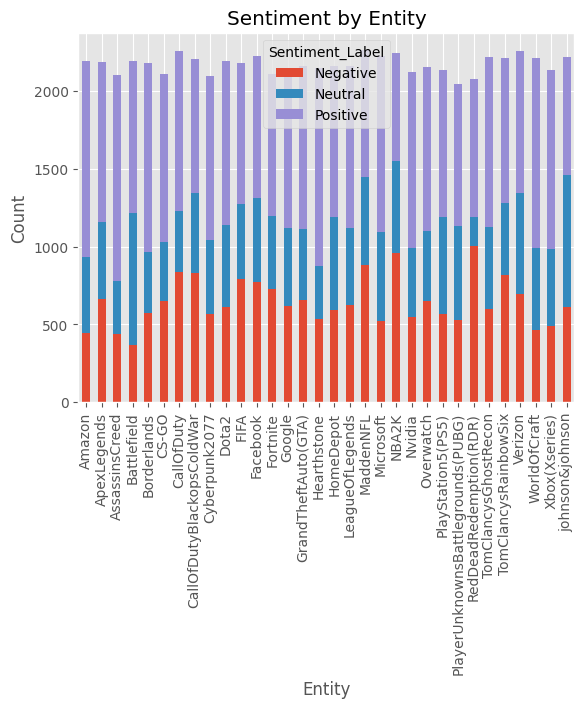

In [110]:
# Analyze sentiment by topic
plt.figure(figsize=(20,10))
sentiment_by_topic = train_data.groupby(['Entity', 'Sentiment_Label']).size().unstack(fill_value=0)
sentiment_by_topic.plot(kind='bar', stacked=True)
plt.title('Sentiment by Entity')
plt.xlabel('Entity')
plt.ylabel('Count')
plt.show()

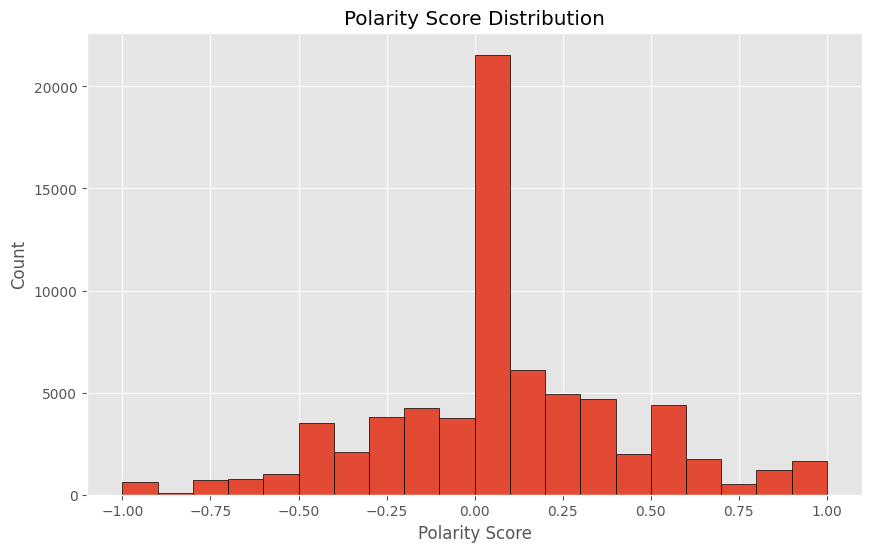

In [111]:
plt.figure(figsize=(10, 6))
plt.hist(train_data['Polarity'], bins=20, edgecolor='k')
plt.title('Polarity Score Distribution')
plt.xlabel('Polarity Score')
plt.ylabel('Count')
plt.show()

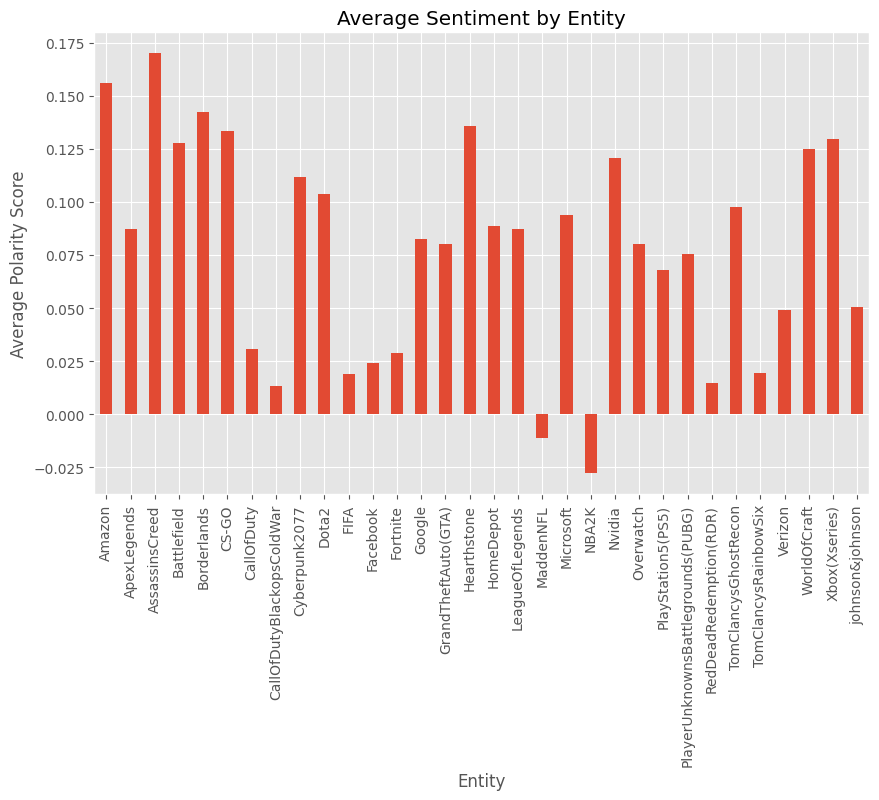

In [112]:
plt.figure(figsize=(10, 6))
average_polarity_by_topic = train_data.groupby('Entity')['Polarity'].mean()
average_polarity_by_topic.plot(kind='bar')
plt.title('Average Sentiment by Entity')
plt.xlabel('Entity')
plt.ylabel('Average Polarity Score')
plt.show()



In [113]:
if "date" in train_data.columns:
    train_data["date"] = pd.to_datetime(train_data["date"], errors="ignore")
    daily_sentiment = df.groupby([train_data["date"].train_data.date, "sentiment"]).size().unstack()
    daily_sentiment.plot(figsize=(12,6))
    plt.title("Sentiment Trend Over Time")
    plt.show()

In [114]:
if "location" in train_data.columns:

    print("Top 20 Locations:",train_data ["location"].value_counts().head(20))

In [115]:
vect = CountVectorizer(ngram_range=(1,2)).fit(train_data['Content'].fillna(''))

# Supervised ML

In [116]:
def polarity(text):
    return TextBlob(text).sentiment.polarity


In [117]:
train_data['polarity'] = train_data['Content'].apply(polarity)

In [118]:
def sentiment(label):
    if label <0:
        return "Negative"
    elif label ==0:
        return "Neutral"
    elif label>0:
        return "Positive"

In [119]:
train_data['Sentiment'] = train_data['polarity'].apply(sentiment)

In [120]:
vect = CountVectorizer(ngram_range=(1,2)).fit(train_data['Content'])

In [121]:
X = train_data['Content']
Y = train_data['Sentiment']
X = vect.transform(X)

In [122]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [123]:
print("Size of x_train:", (x_train.shape))
print("Size of y_train:", (y_train.shape))
print("Size of x_test:", (x_test.shape))
print("Size of y_test:", (y_test.shape))

Size of x_train: (55592, 335336)
Size of y_train: (55592,)
Size of x_test: (13899, 335336)
Size of y_test: (13899,)


In [124]:
import warnings
warnings.filterwarnings('ignore')

# Logistic Regression

In [125]:
logreg = LogisticRegression()
logreg.fit(x_train, y_train)
logreg_pred = logreg.predict(x_test)
logreg_acc = accuracy_score(logreg_pred, y_test)
print("Test accuracy: {:.2f}%".format(logreg_acc*100))

Test accuracy: 93.92%


In [126]:
print(classification_report(y_test, logreg_pred))

              precision    recall  f1-score   support

    Negative       0.94      0.91      0.93      4175
     Neutral       0.90      0.96      0.93      3279
    Positive       0.96      0.95      0.95      6445

    accuracy                           0.94     13899
   macro avg       0.93      0.94      0.94     13899
weighted avg       0.94      0.94      0.94     13899



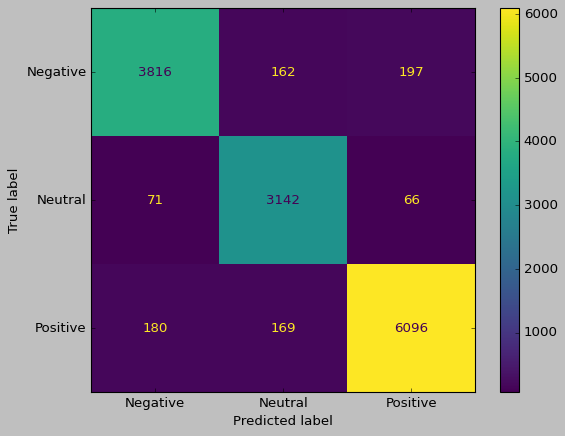

In [127]:
style.use('classic')
cm = confusion_matrix(y_test, logreg_pred, labels=logreg.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=logreg.classes_)
disp.plot()

In [128]:
from sklearn.model_selection import GridSearchCV

In [129]:
param_grid={'C':[0.001, 0.01, 0.1, 1, 10]}
grid = GridSearchCV(LogisticRegression(), param_grid)
grid.fit(x_train, y_train)

GridSearchCV(estimator=LogisticRegression(),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10]})

In [130]:
GridSearchCV(estimator=LogisticRegression(),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10]})


GridSearchCV(estimator=LogisticRegression(),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10]})

In [131]:
print("Best parameters:", grid.best_params_)


Best parameters: {'C': 10}


In [132]:
y_pred = grid.predict(x_test)
logreg_acc = accuracy_score(y_pred, y_test)
print("Test accuracy: {:.2f}%".format(logreg_acc*100))

Test accuracy: 94.14%


In [133]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.94      0.92      0.93      4175
     Neutral       0.92      0.96      0.94      3279
    Positive       0.96      0.95      0.95      6445

    accuracy                           0.94     13899
   macro avg       0.94      0.94      0.94     13899
weighted avg       0.94      0.94      0.94     13899



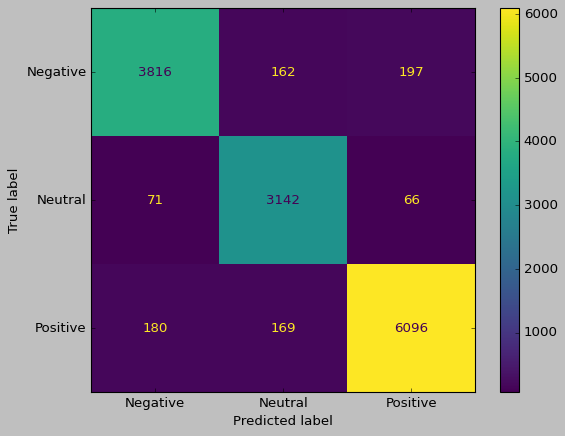

In [134]:
style.use('classic')
cm = confusion_matrix(y_test, logreg_pred, labels=logreg.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=logreg.classes_)
disp.plot()

# SVC

In [135]:
from sklearn.svm import LinearSVC

In [136]:
SVCmodel = LinearSVC()
SVCmodel.fit(x_train, y_train)

LinearSVC()

In [137]:
svc_pred = SVCmodel.predict(x_test)
svc_acc = accuracy_score(svc_pred, y_test)
print("test accuracy: {:.2f}%".format(svc_acc*100))

test accuracy: 94.40%


In [138]:
print(classification_report(y_test, svc_pred))

              precision    recall  f1-score   support

    Negative       0.94      0.92      0.93      4175
     Neutral       0.92      0.96      0.94      3279
    Positive       0.96      0.95      0.95      6445

    accuracy                           0.94     13899
   macro avg       0.94      0.94      0.94     13899
weighted avg       0.94      0.94      0.94     13899



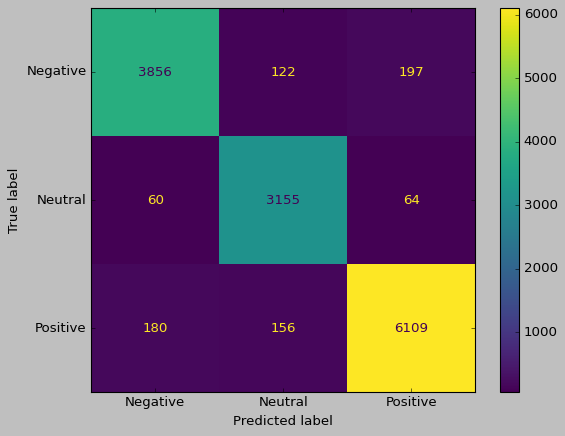

In [139]:
style.use('classic')
cm = confusion_matrix(y_test, svc_pred, labels=logreg.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=logreg.classes_)
disp.plot()

In [140]:
grid = {
    'C':[0.01, 0.1, 1, 10],
    'kernel':["linear","poly","rbf","sigmoid"],
    'degree':[1,3,5,7],
    'gamma':[0.01,1]
}
grid = GridSearchCV(SVCmodel, param_grid)
grid.fit(x_train, y_train)

GridSearchCV(estimator=LinearSVC(), param_grid={'C': [0.001, 0.01, 0.1, 1, 10]})

In [141]:
GridSearchCV(estimator=LinearSVC(), param_grid={'C': [0.001, 0.01, 0.1, 1, 10]})

GridSearchCV(estimator=LinearSVC(), param_grid={'C': [0.001, 0.01, 0.1, 1, 10]})

In [142]:
print("Best parameter:", grid.best_params_)

Best parameter: {'C': 1}


In [143]:
y_pred = grid.predict(x_test)

In [144]:
svc_acc = accuracy_score(y_pred, y_test)
print("Test accuracy: {:.2f}%".format(svc_acc*100))

Test accuracy: 94.40%


In [145]:
print(classification_report(y_test, svc_pred))

              precision    recall  f1-score   support

    Negative       0.94      0.92      0.93      4175
     Neutral       0.92      0.96      0.94      3279
    Positive       0.96      0.95      0.95      6445

    accuracy                           0.94     13899
   macro avg       0.94      0.94      0.94     13899
weighted avg       0.94      0.94      0.94     13899



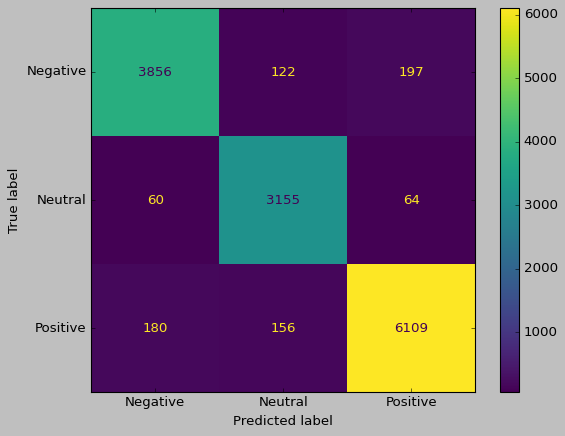

In [146]:
style.use('classic')
cm = confusion_matrix(y_test, svc_pred, labels=logreg.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=logreg.classes_)
disp.plot()

# Unsupervised ML

In [147]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.cluster import KMeans
import pyLDAvis
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')


def display_topics(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        top_words_idx = topic.argsort()[:-n_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(f"Topic {topic_idx}: {' | '.join(top_words)}")

In [148]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

TRAINING_FILE = 'twitter_training.csv'
VALIDATION_FILE = 'twitter_validation.csv'
COLUMNS = ['ID', 'Entity', 'Sentiment', 'text_content']
TEXT_COLUMN = 'text_content'

def load_and_merge_data(training_path, validation_path):
    all_dfs = []

    try:
        train_data = pd.read_csv(training_path, header=None, names=COLUMNS, encoding='utf-8')
        all_dfs.append(train_data)
    except:
        print(f"Error loading {training_path}")
        return pd.DataFrame()

    try:
        valid_data = pd.read_csv(validation_path, header=None, names=COLUMNS, encoding='utf-8')
        all_dfs.append(valid_data)
    except:
        pass

    df_combined = pd.concat(all_dfs, ignore_index=True)
    df_combined = df_combined.dropna(subset=[TEXT_COLUMN])
    print(f"Total Combined Tweets: {len(df_combined)}")

    return df_combined[[TEXT_COLUMN]]

df = load_and_merge_data(TRAINING_FILE, VALIDATION_FILE )

Total Combined Tweets: 74996


In [149]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www.\S+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    stop_words = set(stopwords.words('english'))
    words = text.split()
    words = [word for word in words if word not in stop_words and len(word) > 2]
    return " ".join(words)

df['clean_text'] = df[TEXT_COLUMN].apply(clean_text)

corpus = df[df['clean_text'].str.strip() != '']['clean_text'].tolist()
print(f"Tweets ready for modeling (Corpus Size): {len(corpus)}")

Tweets ready for modeling (Corpus Size): 73308


In [150]:
print("\n  Applying LDA ")

n_topics_lda = 18

vectorizer_lda = TfidfVectorizer(max_df=0.95, min_df=2,stop_words='english',token_pattern=r'\b\w+\b')
data_vectorized_lda = vectorizer_lda.fit_transform(corpus)

lda_model = LatentDirichletAllocation(
    n_components=n_topics_lda,
    max_iter=5,
    learning_method='online',
    random_state=42,
    n_jobs=1
)

lda_model.fit(data_vectorized_lda)

feature_names_lda = vectorizer_lda.get_feature_names_out()
print(f"Top 10 words for {n_topics_lda} LDA Topics:")
display_topics(lda_model, feature_names_lda, 10)



  Applying LDA 
Top 10 words for 18 LDA Topics:
Topic 0: battlefield | good | servers | looks | creed | assassins | god | win | think | smh
Topic 1: awesome | callofduty | great | check | support | look | got | health | thanks | service
Topic 2: years | nbak | true | city | gaming | stock | looking | sold | trump | moments
Topic 3: rhandlerr | watch | google | thank | beautiful | live | friend | come | work | morning
Topic 4: facebook | red | home | fix | update | days | account | broken | card | yall
Topic 5: ranked | event | wanna | phone | app | cancer | crazy | lets | fps | page
Topic 6: nvidia | gta | love | duty | like | nice | game | world | people | use
Topic 7: depot | error | hell | face | remember | gameplay | latest | joke | sweet | daily
Topic 8: dead | redemption | video | pubg | league | super | bad | lol | game | literally
Topic 9: cyberpunk | ubisoft | playstation | selling | day | easy | saying | trial | taking | products
Topic 10: shit | unk | wow | game | time | be

In [151]:
vectorizer_tfidf = TfidfVectorizer(max_df=0.85, min_df=5, stop_words='english')
data_vectorized_tfidf = vectorizer_tfidf.fit_transform(corpus)

print(f"TF-IDF matrix shape: {data_vectorized_tfidf.shape}")

TF-IDF matrix shape: (73308, 14703)


In [152]:
print("\n Applying K-Means on TF-IDF ")
n_clusters_kmeans = 10
kmeans_model = KMeans(n_clusters=n_clusters_kmeans, init='k-means++', max_iter=100, n_init=10, random_state=42)
kmeans_labels = kmeans_model.fit_predict(data_vectorized_tfidf)

df_results = pd.DataFrame({'text_content': corpus, 'KMeans_Cluster': kmeans_labels})

print(f"Cluster Distribution for K-Means (K={n_clusters_kmeans}):")
print(df_results['KMeans_Cluster'].value_counts().sort_index())


 Applying K-Means on TF-IDF 
Cluster Distribution for K-Means (K=10):
KMeans_Cluster
0     1836
1     1511
2      472
3    49603
4     3874
5     1578
6     1125
7     6321
8     3749
9     3239
Name: count, dtype: int64


In [153]:
print("\n Applying NMF ")
n_topics_nmf = n_topics_lda

nmf_model = NMF(
    n_components=n_topics_nmf,
    random_state=42,
    max_iter=200,
    init='nndsvda',
    tol=5e-3
)
nmf_model.fit(data_vectorized_tfidf)

print(f"Top 10 words for {n_topics_nmf} NMF Topics:")
feature_names_nmf = vectorizer_tfidf.get_feature_names_out()
display_topics(nmf_model, feature_names_nmf, 10)


 Applying NMF 
Top 10 words for 18 NMF Topics:
Topic 0: really | play | dont | playing | fun | bad | want | overwatch | people | games
Topic 1: dead | red | redemption | redeeming | online | rockstargames | games | story | live | pictwittercom
Topic 2: love | world | new | warcraft | guys | fortnite | legends | gta | god | borderlands
Topic 3: fuck | fucking | yall | dont | overwatch | ass | man | holy | yes | nbak
Topic 4: unk | happy | storeplaystationcom | nice | better | real | nbak | got | lets | lol
Topic 5: player | ban | battlefield | details | occurred | bfdbcomplayerban | bfdbcom | bfdb | com | pubg
Topic 6: johnson | powder | baby | selling | vaccine | stop | canada | talcbased | covid | talc
Topic 7: good | looks | news | luck | pretty | morning | feels | day | borderlands | man
Topic 8: shit | holy | gta | fucking | fix | dog | lol | ass | nbak | fortnite
Topic 9: wow | token | low | price | change | incredible | thought | high | black | nvidia
Topic 10: rhandlerr | nice 

In [154]:
print("\n Creating pyLDAvis visualization ")

count_vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english', token_pattern=r'\b\w+\b')
data_vectorized_counts = count_vectorizer.fit_transform(corpus)


topic_term_dists = lda_model.components_

doc_topic_dists = lda_model.transform(data_vectorized_lda)

doc_lengths = data_vectorized_counts.sum(axis=1).A1

vocab = count_vectorizer.get_feature_names_out()

term_frequency = data_vectorized_counts.sum(axis=0).A1


lda_vis_data = pyLDAvis.prepare(
    topic_term_dists=topic_term_dists,
    doc_topic_dists=doc_topic_dists,
    doc_lengths=doc_lengths,
    vocab=vocab,
    term_frequency=term_frequency,
    mds='tsne'
)

pyLDAvis.save_html(lda_vis_data, 'lda_topic_visualization.html')

print("pyLDAvis visualization saved to: lda_topic_visualization.html")
print("Please open the HTML file in your browser for interactive topic assessment.")

from google.colab import files
files.download('lda_topic_visualization.html')


 Creating pyLDAvis visualization 
pyLDAvis visualization saved to: lda_topic_visualization.html
Please open the HTML file in your browser for interactive topic assessment.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [155]:
sample_cluster = 0
print(f"\n--- Sample Tweets from K-Means Cluster {sample_cluster} ---")
print(df_results[df_results['KMeans_Cluster'] == sample_cluster]['text_content'].head())


--- Sample Tweets from K-Means Cluster 0 ---
4912    richardturrin amazon partners facebook partner...
6121    bolsonaro vargas evil racist incompetent leade...
6390    join neil neil neil superjam xtra show yes sho...
6422    ih_zee thanks entering grand summoners watch f...
8115    lol lol ruined someones day facebook lol faceb...
Name: text_content, dtype: object


# Deep Learning

In [51]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils import class_weight
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Conv1D, GlobalMaxPooling1D, Input, concatenate, Layer
from tensorflow.keras.callbacks import EarlyStopping


In [4]:
train_data = pd.read_csv("twitter_training.csv", header=None)
valid_data = pd.read_csv("twitter_validation.csv", header=None)


In [5]:
columns = ['Id', 'Entity', 'Sentiment', 'Content']
train_data.columns = columns
valid_data.columns = columns

In [9]:
train_data.head()

,Id,Entity,Sentiment,Content
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [7]:
train_data.tail()

,Id,Entity,Sentiment,Content
74677,9200,Nvidia,Positive,Just realized that the Windows partition of my...
74678,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
74679,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
74680,9200,Nvidia,Positive,Just realized between the windows partition of...
74681,9200,Nvidia,Positive,Just like the windows partition of my Mac is l...


In [10]:
train_data.dropna(subset=['Content'], inplace=True)
valid_data.dropna(subset=['Content'], inplace=True)
train_data['Content'] = train_data['Content'].astype(str)
valid_data['Content'] = valid_data['Content'].astype(str)

In [11]:
sentiment_classes = ['Positive', 'Negative', 'Neutral', 'Irrelevant']
label_mapping = {label: i for i, label in enumerate(sentiment_classes)}
NUM_CLASSES = len(sentiment_classes)

In [12]:
train_data['Sentiment_Code'] = train_data['Sentiment'].map(label_mapping)
valid_data['Sentiment_Code'] = valid_data['Sentiment'].map(label_mapping)

In [14]:
X_train_text = train_data['Content']
X_test_text = valid_data['Content']
y_train = train_data['Sentiment_Code'].values
y_test = valid_data['Sentiment_Code'].values

X_train_text = X_train_text.astype(str).tolist()
X_test_text = X_test_text.astype(str).tolist()
# y_train and y_test are already numpy arrays from .values, so no need to convert again.
# y_train = np.array(y_train)
# y_test = np.array(y_test)


In [15]:
X_train_text = train_data['Content']
y_train = train_data['Sentiment_Code'].values
X_test_text = valid_data['Content']
y_test = valid_data['Sentiment_Code'].values

In [16]:
print("Traditional Baseline Model (TF-IDF + LR) Evaluation")

baseline_model = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1, 2))),
    ('clf', LogisticRegression(solver='liblinear', class_weight='balanced', max_iter=200))
])

baseline_model.fit(X_train_text, y_train)
y_pred_baseline = baseline_model.predict(X_test_text)

Traditional Baseline Model (TF-IDF + LR) Evaluation


In [17]:
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
print(f"Baseline Accuracy: {accuracy_baseline:.4f}")
print(classification_report(y_test, y_pred_baseline, target_names=sentiment_classes))

Baseline Accuracy: 0.9100
              precision    recall  f1-score   support

    Positive       0.88      0.91      0.90       277
    Negative       0.91      0.93      0.92       266
     Neutral       0.92      0.90      0.91       285
  Irrelevant       0.92      0.90      0.91       172

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000



In [18]:
MAX_WORDS = 20000
MAX_LEN = 256
EMBEDDING_DIM = 128
NUM_CLASSES = len(np.unique(y_train))

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<unk>")
tokenizer.fit_on_texts(X_train_text)

X_train_padded = pad_sequences(tokenizer.texts_to_sequences(X_train_text), maxlen=MAX_LEN, padding='post', truncating='post')
X_test_padded = pad_sequences(tokenizer.texts_to_sequences(X_test_text), maxlen=MAX_LEN, padding='post', truncating='post')

VOCAB_SIZE = min(MAX_WORDS, len(tokenizer.word_index) + 1)
print(f"\nDL Model Parameters: VOCAB_SIZE={VOCAB_SIZE}, MAX_LEN={MAX_LEN}, NUM_CLASSES={NUM_CLASSES}")


DL Model Parameters: VOCAB_SIZE=20000, MAX_LEN=256, NUM_CLASSES=4


In [19]:
# Compute class weights for DL models
class_weights_array = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights_array))
print("Class weights:", class_weights_dict)


Class weights: {0: np.float64(0.8956184943113048), 1: np.float64(0.8273995885141784), 2: np.float64(1.0215926662248729), 3: np.float64(1.4368155339805826)}


In [20]:
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

In [21]:
def create_lstm_model():
    model = Sequential([
        Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
        LSTM(128),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model



In [25]:
lstm_model = create_lstm_model()
history = lstm_model.fit(
    X_train_padded, y_train,
    validation_data=(X_test_padded, y_test),
    epochs=10,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
2313/2313 ━━━━━━━━━━━━━━━━━━━━ 38s 15ms/step - accuracy: 0.2435 - loss: 1.3888 - val_accuracy: 0.2660 - val_loss: 1.3849
Epoch 2/10
2313/2313 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - accuracy: 0.2512 - loss: 1.3873 - val_accuracy: 0.2850 - val_loss: 1.3858
Epoch 3/10
2313/2313 ━━━━━━━━━━━━━━━━━━━━ 35s 15ms/step - accuracy: 0.2453 - loss: 1.3877 - val_accuracy: 0.2770 - val_loss: 1.3851


In [30]:
def create_cnn_model():
    filter_sizes = [3, 4, 5]
    num_filters = 100

    inputs = Input(shape=(MAX_LEN,))
    embedding = Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN)(inputs)

    conv_blocks = []
    for fsize in filter_sizes:
        conv = Conv1D(filters=num_filters, kernel_size=fsize, activation='relu')(embedding)
        pool = GlobalMaxPooling1D()(conv)
        conv_blocks.append(pool)

    z = concatenate(conv_blocks)
    z = Dropout(0.5)(z)
    outputs = Dense(NUM_CLASSES, activation='softmax')(z)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model



In [31]:
cnn_model = create_cnn_model()

history_cnn = cnn_model.fit(
    X_train_padded, y_train,
    validation_data=(X_test_padded, y_test),
    epochs=10,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
2313/2313 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - accuracy: 0.5662 - loss: 1.0165 - val_accuracy: 0.9280 - val_loss: 0.2311
Epoch 2/10
2313/2313 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.8886 - loss: 0.3046 - val_accuracy: 0.9510 - val_loss: 0.1633
Epoch 3/10
2313/2313 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.9274 - loss: 0.1900 - val_accuracy: 0.9600 - val_loss: 0.1754
Epoch 4/10
2313/2313 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.9433 - loss: 0.1442 - val_accuracy: 0.9490 - val_loss: 0.2205


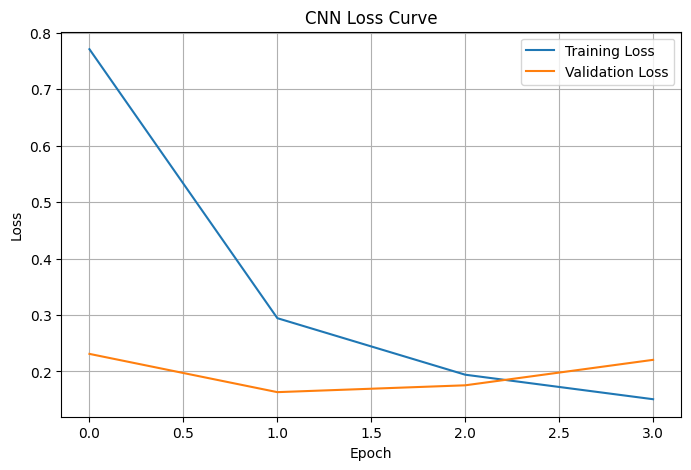

In [34]:
# ---- CNN Loss Curve ----
plt.figure(figsize=(8, 5))
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

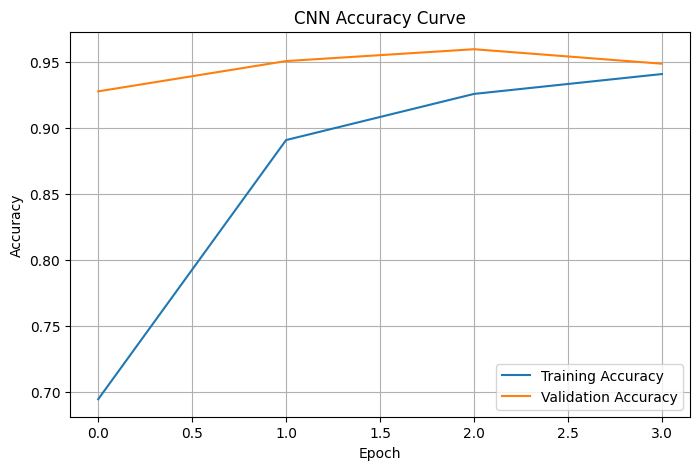

In [33]:
# ---- CNN Accuracy Curve ----
plt.figure(figsize=(8, 5))
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


In [41]:
model = cnn_model

y_pred_probs = model.predict(X_test_padded)

y_pred = np.argmax(y_pred_probs, axis=1)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [42]:
cm = confusion_matrix(y_test, y_pred)


<Figure size 600x500 with 0 Axes>

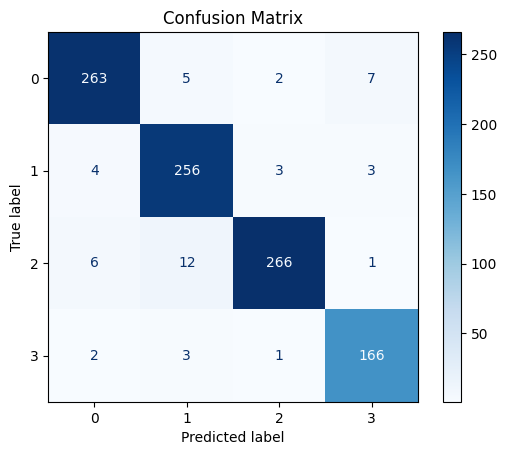

In [43]:
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix")
plt.show()


In [44]:
class AttentionLayer(Layer):
    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1),
                                 initializer='glorot_uniform',
                                 trainable=True)
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        u = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W))
        a = tf.keras.backend.softmax(u, axis=1)
        self.attention_weights = a
        output = x * a
        output = tf.keras.backend.sum(output, axis=1)
        return output


In [45]:
def create_attention_lstm_model():
    inputs = Input(shape=(MAX_LEN,))
    embedding = Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN)(inputs)
    lstm_out = LSTM(128, return_sequences=True)(embedding)
    attention_out = AttentionLayer()(lstm_out)
    outputs = Dense(NUM_CLASSES, activation='softmax')(attention_out)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

attention_lstm_model = create_attention_lstm_model()
attention_lstm_model.fit(
    X_train_padded, y_train,
    validation_data=(X_test_padded, y_test),
    epochs=10,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
2313/2313 ━━━━━━━━━━━━━━━━━━━━ 38s 15ms/step - accuracy: 0.4266 - loss: 1.2063 - val_accuracy: 0.8780 - val_loss: 0.3899
Epoch 2/10
2313/2313 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - accuracy: 0.8499 - loss: 0.4201 - val_accuracy: 0.9470 - val_loss: 0.2010
Epoch 3/10
2313/2313 ━━━━━━━━━━━━━━━━━━━━ 34s 15ms/step - accuracy: 0.9075 - loss: 0.2491 - val_accuracy: 0.9510 - val_loss: 0.1660
Epoch 4/10
2313/2313 ━━━━━━━━━━━━━━━━━━━━ 35s 15ms/step - accuracy: 0.9284 - loss: 0.1850 - val_accuracy: 0.9640 - val_loss: 0.1543
Epoch 5/10
2313/2313 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - accuracy: 0.9414 - loss: 0.1489 - val_accuracy: 0.9600 - val_loss: 0.1654
Epoch 6/10
2313/2313 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - accuracy: 0.9512 - loss: 0.1229 - val_accuracy: 0.9530 - val_loss: 0.1913


In [50]:
from transformers import DistilBertTokenizerFast, TFDistilBertForSequenceClassification, create_optimizer
import tensorflow as tf
import pandas as pd

MAX_LEN_BERT = 100
BATCH_SIZE_BERT = 16
EPOCHS_BERT = 4

tokenizer_bert = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

# Ensure inputs are lists of strings
X_train_text = X_train_text.astype(str).tolist() if isinstance(X_train_text, pd.Series) else [str(x) for x in X_train_text]
X_test_text  = X_test_text.astype(str).tolist()  if isinstance(X_test_text, pd.Series) else [str(x) for x in X_test_text]

train_encodings = tokenizer_bert(X_train_text, truncation=True, padding=True, max_length=MAX_LEN_BERT)
test_encodings  = tokenizer_bert(X_test_text, truncation=True, padding=True, max_length=MAX_LEN_BERT)

train_dataset = tf.data.Dataset.from_tensor_slices((dict(train_encodings), y_train)).shuffle(1000).batch(BATCH_SIZE_BERT)
test_dataset  = tf.data.Dataset.from_tensor_slices((dict(test_encodings), y_test)).batch(BATCH_SIZE_BERT)

num_train_steps = len(X_train_text) // BATCH_SIZE_BERT * EPOCHS_BERT
if len(X_train_text) % BATCH_SIZE_BERT != 0:
    num_train_steps += EPOCHS_BERT

    distilbert_model = TFDistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=NUM_CLASSES,
    force_download=True,
    use_safetensors=False
)

optimizer, lr_schedule = create_optimizer(
    init_lr=2e-5,
    num_warmup_steps=0,
    num_train_steps=num_train_steps,
    weight_decay_rate=0.01
)

distilbert_model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

distilbert_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS_BERT
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tf_model.h5:   0%|          | 0.00/363M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some layers from the model checkpoint at distilbert-base-uncased were not used when initializing TFDistilBertForSequenceClassification: ['activation_13', 'vocab_layer_norm', 'vocab_transform', 'vocab_projector']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFDistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-

Epoch 1/4
4625/4625 [==============================] - 879s 187ms/step - loss: 0.7254 - accuracy: 0.7274 - val_loss: 0.8695 - val_accuracy: 0.6920
Epoch 2/4
4625/4625 [==============================] - 832s 180ms/step - loss: 0.3333 - accuracy: 0.8809 - val_loss: 0.6008 - val_accuracy: 0.8220
Epoch 3/4
4625/4625 [==============================] - 831s 180ms/step - loss: 0.1755 - accuracy: 0.9369 - val_loss: 0.5138 - val_accuracy: 0.8650
Epoch 4/4
4625/4625 [==============================] - 831s 180ms/step - loss: 0.1432 - accuracy: 0.9463 - val_loss: 0.2485 - val_accuracy: 0.9340


In [52]:
# ----- Predictions & Attention Weights -----
def bert_predict(model, dataset):
    preds = model.predict(dataset)
    logits = preds.logits if hasattr(preds, "logits") else preds
    return np.argmax(logits, axis=1)

y_pred_lstm = np.argmax(lstm_model.predict(X_test_padded), axis=1)
y_pred_cnn = np.argmax(cnn_model.predict(X_test_padded), axis=1)
y_pred_att = np.argmax(attention_lstm_model.predict(X_test_padded), axis=1)
y_pred_bert = bert_predict(distilbert_model, test_dataset)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
63/63 [==============================] - 5s 58ms/step


In [53]:
# Confusion matrix & classification reports
for name, y_pred in zip(
    ['LSTM','CNN','Attention-LSTM','DistilBERT'],
    [y_pred_lstm, y_pred_cnn, y_pred_att, y_pred_bert]
):
    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred, target_names=sentiment_classes))


LSTM Classification Report:
              precision    recall  f1-score   support

    Positive       0.00      0.00      0.00       277
    Negative       0.27      1.00      0.42       266
     Neutral       0.00      0.00      0.00       285
  Irrelevant       0.00      0.00      0.00       172

    accuracy                           0.27      1000
   macro avg       0.07      0.25      0.11      1000
weighted avg       0.07      0.27      0.11      1000


CNN Classification Report:
              precision    recall  f1-score   support

    Positive       0.96      0.95      0.95       277
    Negative       0.93      0.96      0.94       266
     Neutral       0.98      0.93      0.96       285
  Irrelevant       0.94      0.97      0.95       172

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000


Attention-LSTM Classification Report:
              precision    recall 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
